# Exploratory analysis — Q3, Q10 and Q13

This notebook performs an initial exploration of:

- **Q3:** Which meteorological and hydrological conditions are associated with observed flood occurrence?
- **Q10:** Are these conditions consistent across different years and regions?
- **Q13:** How do local rainfall and upstream hydrological signals differ across flood events and regions?

The purpose is to determine which questions show enough interesting signal to justify further analysis.

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from processing_data.loading import *

In [3]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Move notebook execution to project root
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

print("Working directory:", Path.cwd())

import processing_data.loading as loading

Working directory: c:\Users\20242408\OneDrive - TU Eindhoven\Documenten\DATA SCIENCE BACHELOR\Jaar 3\Q1\Capstone data challenge\JBG060_ZHL_2026


In [4]:
# This cell inspects the available data-loading functions and their documentation.
# It outputs each function's arguments and description so we can identify which
# datasets are relevant for exploring research questions Q3, Q10, and Q13.

import inspect

for func_name in [
    "load_flood_masks",
    "load_rainfall_runoff",
    "load_dartmouth_data",
    "load_lake_stations"
]:
    func = getattr(loading, func_name)

    print("\n", func_name)
    print(inspect.signature(func))
    print(inspect.getdoc(func))


 load_flood_masks
(years: <built-in function array>, bbox: dict = None) -> pandas.DataFrame
Loads the compact flood mask parquet files for all given years and both tiles (together spanning South Sudan),
and merges the recurring and unusual flood events into a single DataFrame.

For each (date, lat, lon) combination:
- flood_type = 0 if recurring flood.
- flood_type = 1 if unusual flood.
If a pixel appears in both, unusual (1) takes priority.

Data downloaded from:
https://www.earthdata.nasa.gov/data/instruments/viirs/near-real-time-data/nrt-global-flood-products
Specifically, we load post-processed 3-day flood mask MCDWD_L3_NRT data.

The raw data is distributed in 10x10° tiles, the two tiles together span South Sudan.
The tiles are 4800 x 4800 pixels, with pixel size of 0.0020833 degrees (~232 m at the equator). 
It contains each location and day at which a recurring and unusual flood was detected, for the 3-day composite.

This product sums over 3 days of data, and requires multiple

In [5]:
# This cell loads the main datasets used in the exploratory analysis for 2020–2022:
# flood-mask observations, ERA5 rainfall/runoff, and Dartmouth river discharge.
# It outputs basic information about each dataset to verify that the data loaded
# correctly and to understand its structure before starting the analysis.

import numpy as np

years = np.arange(2020, 2023)

flood_masks = loading.load_flood_masks(years=years)

rainfall_runoff = loading.load_rainfall_runoff(years=years)

discharge = loading.load_dartmouth_data()

print("Flood masks:")
print(type(flood_masks))
print(flood_masks.head())
print(flood_masks.columns)

print("\nRainfall/runoff:")
print(rainfall_runoff)

print("\nDischarge:")
print(type(discharge))
print(discharge.keys())

Daily total precipitation and runoff from ERA5 reanalysis loaded from dates 2020-01-01 to 2022-12-31
<xarray.Dataset> Size: 72MB
Dimensions:     (valid_time: 1096, latitude: 145, longitude: 57)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 9kB 2020-01-01 ... 2022-12-31
  * latitude    (latitude) float64 1kB 33.0 32.75 32.5 32.25 ... -2.5 -2.75 -3.0
  * longitude   (longitude) float64 456B 23.0 23.25 23.5 ... 36.5 36.75 37.0
    number      int64 8B 0
Data variables:
    tp          (valid_time, latitude, longitude) float32 36MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
    ro          (valid_time, latitude, longitude) float32 36MB dask.array<chunksize=(1, 145, 57), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:   

In [6]:
# This cell defines a study area around Malakal and selects all detected flood
# pixels within that bounding box. It outputs the number of flood observations,
# number of dates with flooding, and a sample of the selected flood-mask data.

bbox_malakal = {
    "lon_min": 31.3,
    "lon_max": 31.9,
    "lat_min": 9.2,
    "lat_max": 9.9
}

flood_area = flood_masks[
    (flood_masks["lon"] >= bbox_malakal["lon_min"]) &
    (flood_masks["lon"] <= bbox_malakal["lon_max"]) &
    (flood_masks["lat"] >= bbox_malakal["lat_min"]) &
    (flood_masks["lat"] <= bbox_malakal["lat_max"])
].copy()

print("Flood observations:", len(flood_area))
print("Dates with flooding:", flood_area["date"].nunique())

flood_area.head()

Flood observations: 217002
Dates with flooding: 532


,date,lat,lon,tile,flood_type
30816,2020-01-02,9.346875,31.471874,h21v08,1
30817,2020-01-02,9.346875,31.473959,h21v08,1
30818,2020-01-02,9.346875,31.476042,h21v08,1
31077,2020-01-02,9.415625,31.582293,h21v08,0
95516,2020-01-07,9.317708,31.878124,h21v08,1


In [7]:
# This cell aggregates the Malakal flood observations by date and counts the
# number of detected flooded pixels per day. It outputs a daily flood-extent
# time series that can be compared with meteorological and hydrological variables.

daily_flood = (
    flood_area
    .groupby("date")
    .size()
    .rename("flood_pixels")
    .reset_index()
)

daily_flood["date"] = pd.to_datetime(daily_flood["date"])

daily_flood.head()

,date,flood_pixels
0,2020-01-02,4
1,2020-01-07,26
2,2020-01-09,17
3,2020-01-10,6
4,2020-01-11,15


In [8]:
daily_flood_type = (
    flood_area
    .groupby(["date", "flood_type"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={
        0: "recurring_pixels",
        1: "unusual_pixels"
    })
    .reset_index()
)

daily_flood_type.head()

flood_type,date,recurring_pixels,unusual_pixels
0,2020-01-02,1,3
1,2020-01-07,7,19
2,2020-01-09,4,13
3,2020-01-10,2,4
4,2020-01-11,2,13


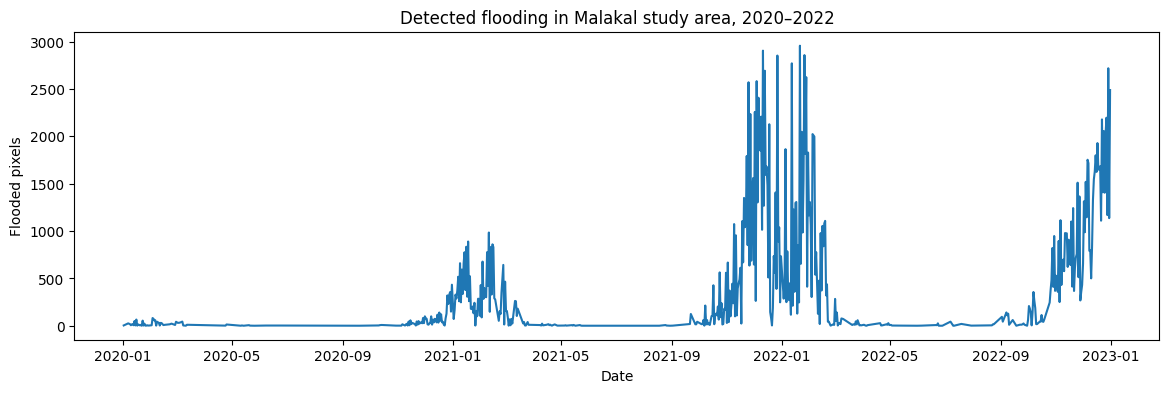

In [9]:
# This cell visualizes the daily number of detected flooded pixels around Malakal
# from 2020–2022. It outputs a time-series plot showing when major flood periods
# occurred and how their observed extent changed through time.

plt.figure(figsize=(14, 4))

plt.plot(
    daily_flood["date"],
    daily_flood["flood_pixels"]
)

plt.ylabel("Flooded pixels")
plt.xlabel("Date")
plt.title("Detected flooding in Malakal study area, 2020–2022")

plt.show()

In [10]:
# This cell extracts ERA5 rainfall and runoff over the Malakal study area and
# spatially averages the grid cells for each day. It converts the original
# metre-based values to mm/day and outputs a daily rainfall/runoff time series.

rr_area = rainfall_runoff.sel(
    longitude=slice(
        bbox_malakal["lon_min"],
        bbox_malakal["lon_max"]
    ),
    latitude=slice(
        bbox_malakal["lat_max"],
        bbox_malakal["lat_min"]
    )
)

rr_daily = (
    rr_area[["tp", "ro"]]
    .mean(dim=["latitude", "longitude"])
    .to_dataframe()
    .reset_index()
)

rr_daily = rr_daily.rename(columns={
    "valid_time": "date",
    "tp": "rainfall_mm",
    "ro": "runoff_mm"
})

# ERA5 is currently in metres/day → convert to mm/day
rr_daily["rainfall_mm"] *= 1000
rr_daily["runoff_mm"] *= 1000

rr_daily.head()

,date,rainfall_mm,runoff_mm,number
0,2020-01-01,0.0,0.0,0
1,2020-01-02,0.0,0.0,0
2,2020-01-03,0.0,0.0,0
3,2020-01-04,0.0,0.0,0
4,2020-01-05,0.0,0.0,0


In [11]:
# This cell combines the Malakal rainfall/runoff time series with daily flood
# extent. Days without detected flooding are assigned zero flooded pixels, and
# a binary flood-occurrence variable is created for later comparisons.

df = rr_daily.merge(
    daily_flood,
    on="date",
    how="left"
)

# Dates absent from flood_masks = no detected flooding
df["flood_pixels"] = df["flood_pixels"].fillna(0)

df["flood_occurrence"] = (
    df["flood_pixels"] > 0
).astype(int)

# Calculate accumulated rainfall over the current and previous six days.
# This adds a 7-day rainfall variable to test whether recent rainfall corresponds
# more closely with observed flooding than rainfall on the same day.

df["rainfall_7d"] = (
    df["rainfall_mm"]
    .rolling(7)
    .sum()
)

df.head()

,date,rainfall_mm,runoff_mm,number,flood_pixels,flood_occurrence,rainfall_7d
0,2020-01-01,0.0,0.0,0,0.0,0,NaN
1,2020-01-02,0.0,0.0,0,4.0,1,NaN
2,2020-01-03,0.0,0.0,0,0.0,0,NaN
3,2020-01-04,0.0,0.0,0,0.0,0,NaN
4,2020-01-05,0.0,0.0,0,0.0,0,NaN


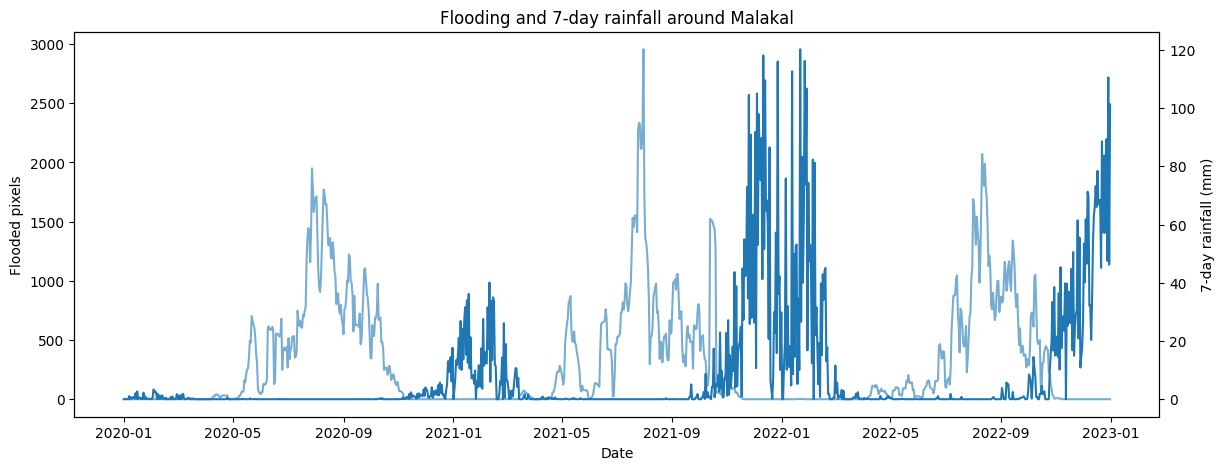

In [12]:
# This cell compares Malakal flood extent with accumulated 7-day local rainfall.
# It outputs both variables on the same time axis to visually examine whether
# rainfall peaks occur before, during, or independently of major flood periods.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    df["date"],
    df["flood_pixels"],
    label="Flooded pixels"
)

ax1.set_ylabel("Flooded pixels")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(
    df["date"],
    df["rainfall_7d"],
    alpha=0.6,
    label="7-day rainfall"
)

ax2.set_ylabel("7-day rainfall (mm)")

plt.title("Flooding and 7-day rainfall around Malakal")
plt.show()

In [13]:
# This cell extracts Dartmouth discharge station 100205, located near Malakal,
# and prepares its date and discharge columns for merging with the other daily
# variables. It outputs a clean discharge time series for the study period.

malakal_discharge = discharge[100205].copy()

print(malakal_discharge.head())
print(malakal_discharge.tail())
print(malakal_discharge.index)

            Discharge (m3/s)
Date                        
1998-01-01       5769.000000
1998-01-02       5777.155983
1998-01-03       5723.721571
1998-01-04       5673.786942
1998-01-05       5673.786942
            Discharge (m3/s)
Date                        
2026-05-15       5600.218291
2026-05-16       5600.218291
2026-05-17       5981.671033
2026-05-18       6120.157972
2026-05-19       6143.291741
DatetimeIndex(['1998-01-01', '1998-01-02', '1998-01-03', '1998-01-04',
               '1998-01-05', '1998-01-06', '1998-01-07', '1998-01-08',
               '1998-01-09', '1998-01-10',
               ...
               '2026-05-10', '2026-05-11', '2026-05-12', '2026-05-13',
               '2026-05-14', '2026-05-15', '2026-05-16', '2026-05-17',
               '2026-05-18', '2026-05-19'],
              dtype='datetime64[us]', name='Date', length=10366, freq=None)


In [14]:
# This cell adds the Dartmouth discharge measurements near Malakal to the main
# analysis dataframe by matching observations by date. It outputs an expanded
# daily dataset containing flooding, rainfall, runoff, and river discharge.

malakal_discharge = malakal_discharge.reset_index()

malakal_discharge = malakal_discharge.rename(columns={
    "Date": "date",
    "Discharge (m3/s)": "discharge"
})

malakal_discharge["date"] = pd.to_datetime(
    malakal_discharge["date"]
)

malakal_discharge.head()

,date,discharge
0,1998-01-01,5769.000000
1,1998-01-02,5777.155983
2,1998-01-03,5723.721571
3,1998-01-04,5673.786942
4,1998-01-05,5673.786942


In [15]:
df = df.merge(
    malakal_discharge[["date", "discharge"]],
    on="date",
    how="left"
)

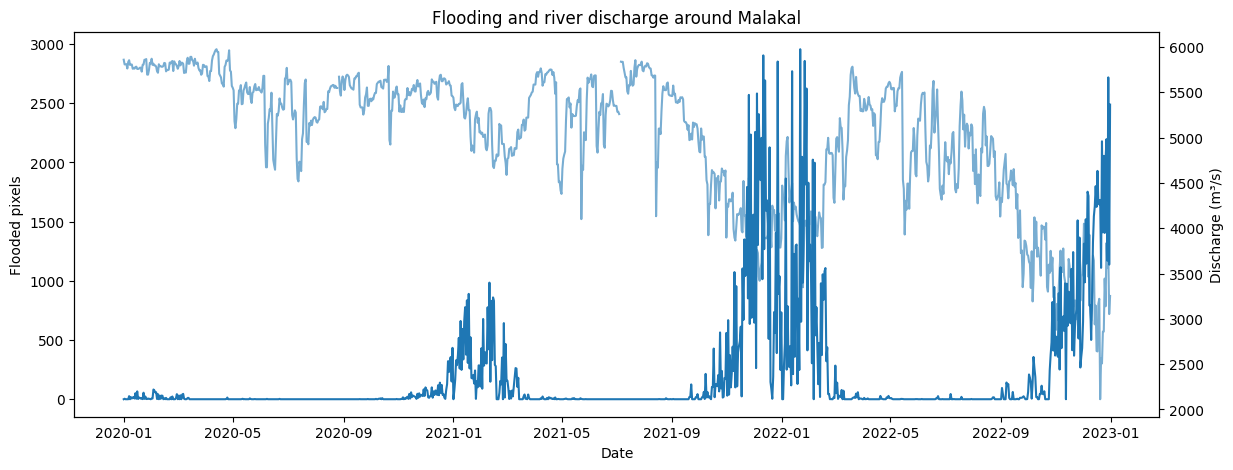

In [16]:
# This cell compares observed flood extent around Malakal with river discharge
# from Dartmouth station 100205. It outputs both time series together to explore
# whether high discharge coincides with or precedes major flood periods.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    df["date"],
    df["flood_pixels"]
)

ax1.set_ylabel("Flooded pixels")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(
    df["date"],
    df["discharge"],
    alpha=0.6
)

ax2.set_ylabel("Discharge (m³/s)")

plt.title("Flooding and river discharge around Malakal")
plt.show()

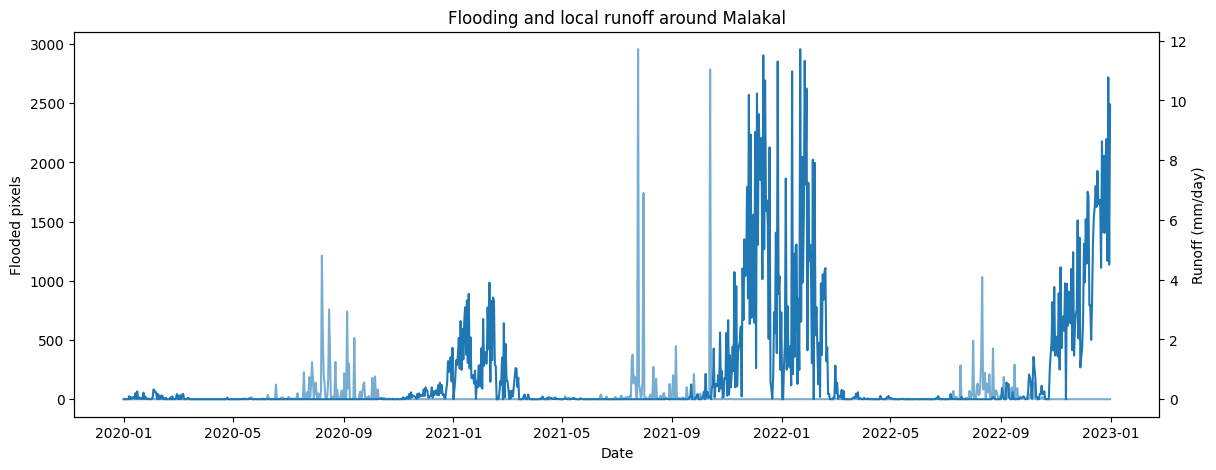

In [110]:
# This cell compares observed flood extent around Malakal with local ERA5 runoff.
# It outputs both variables on the same time axis to visually assess whether
# runoff peaks correspond with periods of extensive flooding.

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(
    df["date"],
    df["flood_pixels"]
)

ax1.set_ylabel("Flooded pixels")
ax1.set_xlabel("Date")

ax2 = ax1.twinx()

ax2.plot(
    df["date"],
    df["runoff_mm"],
    alpha=0.6
)

ax2.set_ylabel("Runoff (mm/day)")

plt.title("Flooding and local runoff around Malakal")
plt.show()

In [111]:
# This cell compares median meteorological and hydrological conditions between
# days with and without detected flooding around Malakal. It outputs median
# rainfall, 7-day rainfall, runoff, and discharge for the two groups.

df["rainfall_7d"] = df["rainfall_mm"].rolling(7).sum()

summary = df.groupby("flood_occurrence")[
    ["rainfall_mm", "rainfall_7d", "runoff_mm", "discharge"]
].median()

summary.index = ["No flood", "Flood"]

summary

,rainfall_mm,rainfall_7d,runoff_mm,discharge
No flood,0.458837,15.488068,0.003179,5389.194963
Flood,0.000000,0.000000,0.000000,4864.649051


In [112]:
# This cell calculates simple same-day correlations between Malakal flood extent
# and rainfall, accumulated rainfall, runoff, and discharge. It outputs correlation
# coefficients as a quick exploratory measure of the strength and direction of
# each relationship; these correlations are descriptive and do not imply causation.

df[
    ["flood_pixels", "rainfall_mm", "rainfall_7d", "runoff_mm", "discharge"]
].corr()["flood_pixels"].sort_values(ascending=False)

flood_pixels    1.000000
runoff_mm      -0.064442
rainfall_mm    -0.164583
rainfall_7d    -0.263318
discharge      -0.585497
Name: flood_pixels, dtype: float64

In [113]:
# This cell calculates accumulated rainfall over 7, 14, 30, and 60-day windows
# around Malakal. It outputs correlations between each rainfall window and flood
# extent to test whether longer-term antecedent rainfall shows a stronger
# relationship with flooding than short-term rainfall.

for days in [7, 14, 30, 60]:
    df[f"rainfall_{days}d"] = (
        df["rainfall_mm"]
        .rolling(window=days, min_periods=days)
        .sum()
    )

# Correlation between flood extent and accumulated rainfall
rainfall_corr = df[
    [
        "flood_pixels",
        "rainfall_7d",
        "rainfall_14d",
        "rainfall_30d",
        "rainfall_60d"
    ]
].corr()["flood_pixels"]

rainfall_corr

flood_pixels    1.000000
rainfall_7d    -0.263318
rainfall_14d   -0.278886
rainfall_30d   -0.281432
rainfall_60d   -0.230135
Name: flood_pixels, dtype: float64

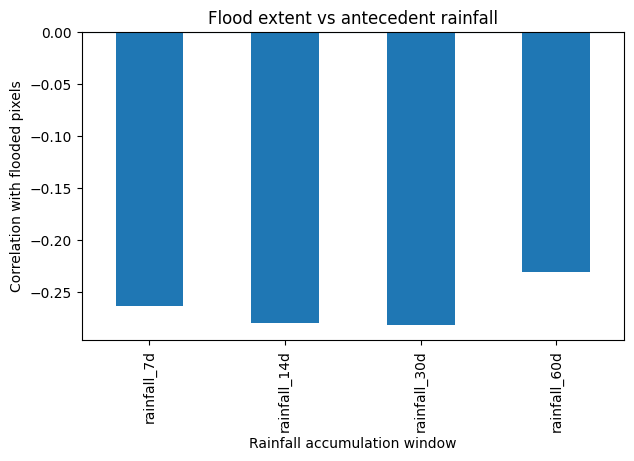

In [114]:
# This cell visualizes the correlation between Malakal flood extent and each
# antecedent rainfall window. It outputs a bar chart that makes it easier to
# compare whether short- or long-term accumulated rainfall is more strongly
# associated with observed flooding.

rainfall_corr.drop("flood_pixels").plot(
    kind="bar",
    figsize=(7, 4)
)

plt.axhline(0)
plt.ylabel("Correlation with flooded pixels")
plt.xlabel("Rainfall accumulation window")
plt.title("Flood extent vs antecedent rainfall")
plt.show()

### Preliminary observation — Malakal

Across the tested 7, 14, 30 and 60-day windows, antecedent local
rainfall remains negatively correlated with observed flood extent.
Increasing the accumulation period therefore does not reveal a simple
positive rainfall–flood relationship.

This does not imply that rainfall reduces flooding. Instead, the result
suggests that temporal offsets, flood persistence, seasonality, or
upstream hydrological processes may be important and should be explored
further.

In [115]:
# This cell defines a study area around Bentiu (Unity State), selects all detected
# flood pixels inside that area, and outputs the number of flood observations,
# number of flood days, and the first few observations for a quick data check.

bbox_bentiu = {
    "lon_min": 29.5,
    "lon_max": 30.1,
    "lat_min": 9.0,
    "lat_max": 9.6
}

flood_bentiu = flood_masks[
    (flood_masks["lon"] >= bbox_bentiu["lon_min"]) &
    (flood_masks["lon"] <= bbox_bentiu["lon_max"]) &
    (flood_masks["lat"] >= bbox_bentiu["lat_min"]) &
    (flood_masks["lat"] <= bbox_bentiu["lat_max"])
].copy()

print("Flood observations:", len(flood_bentiu))
print("Dates with flooding:", flood_bentiu["date"].nunique())

flood_bentiu.head()

Flood observations: 3782459
Dates with flooding: 601


,date,lat,lon,tile,flood_type
64634,2020-01-05,9.426042,30.073957,h21v08,0
297834,2020-01-14,9.423959,30.069792,h21v08,1
297835,2020-01-14,9.423959,30.071875,h21v08,1
297939,2020-01-14,9.428125,30.078125,h21v08,0
297940,2020-01-14,9.428125,30.080208,h21v08,1


In [116]:
# This cell counts the number of detected flooded pixels per day around Bentiu.
# It outputs a daily time series called daily_flood_bentiu that we can compare
# directly with rainfall, runoff, and the previous Malakal results.

daily_flood_bentiu = (
    flood_bentiu
    .groupby("date")
    .size()
    .reset_index(name="flood_pixels")
)

daily_flood_bentiu["date"] = pd.to_datetime(daily_flood_bentiu["date"])

daily_flood_bentiu.head()

,date,flood_pixels
0,2020-01-05,1
1,2020-01-14,4
2,2020-01-16,1
3,2020-01-24,2
4,2020-01-25,3


In [117]:
# This cell extracts ERA5 rainfall and runoff over the Bentiu study area,
# spatially averages them for each day, converts metres to millimetres,
# and outputs one daily rainfall/runoff time series for Bentiu.

rr_bentiu = rainfall_runoff.sel(
    longitude=slice(
        bbox_bentiu["lon_min"],
        bbox_bentiu["lon_max"]
    ),
    latitude=slice(
        bbox_bentiu["lat_max"],
        bbox_bentiu["lat_min"]
    )
)

rr_daily_bentiu = (
    rr_bentiu[["tp", "ro"]]
    .mean(dim=["latitude", "longitude"])
    .to_dataframe()
    .reset_index()
)

rr_daily_bentiu = rr_daily_bentiu.rename(columns={
    "valid_time": "date",
    "tp": "rainfall_mm",
    "ro": "runoff_mm"
})

rr_daily_bentiu["rainfall_mm"] *= 1000
rr_daily_bentiu["runoff_mm"] *= 1000

rr_daily_bentiu.head()

,date,rainfall_mm,runoff_mm,number
0,2020-01-01,0.0,0.0,0
1,2020-01-02,0.0,0.0,0
2,2020-01-03,0.0,0.0,0
3,2020-01-04,0.0,0.0,0
4,2020-01-05,0.0,0.0,0


In [118]:
# This cell combines Bentiu's daily rainfall/runoff data with detected flooding.
# Days without detected flood pixels are assigned zero flooding, and a binary
# flood-occurrence variable is created. The output is the main Bentiu dataframe.

df_bentiu = rr_daily_bentiu.merge(
    daily_flood_bentiu,
    on="date",
    how="left"
)

df_bentiu["flood_pixels"] = df_bentiu["flood_pixels"].fillna(0)

df_bentiu["flood_occurrence"] = (
    df_bentiu["flood_pixels"] > 0
).astype(int)

df_bentiu.head()

,date,rainfall_mm,runoff_mm,number,flood_pixels,flood_occurrence
0,2020-01-01,0.0,0.0,0,0.0,0
1,2020-01-02,0.0,0.0,0,0.0,0
2,2020-01-03,0.0,0.0,0,0.0,0
3,2020-01-04,0.0,0.0,0,0.0,0
4,2020-01-05,0.0,0.0,0,1.0,1


In [119]:
# This cell calculates accumulated rainfall over the previous 7, 14, 30 and
# 60 days around Bentiu. It outputs these as new columns in df_bentiu so we
# can test whether longer-term rainfall relates more strongly to flooding.

for days in [7, 14, 30, 60]:
    df_bentiu[f"rainfall_{days}d"] = (
        df_bentiu["rainfall_mm"]
        .rolling(window=days, min_periods=days)
        .sum()
    )

df_bentiu[
    ["date", "rainfall_mm", "rainfall_7d",
     "rainfall_14d", "rainfall_30d", "rainfall_60d"]
].head(65)

,date,rainfall_mm,rainfall_7d,rainfall_14d,rainfall_30d,rainfall_60d
0,2020-01-01,0.0,NaN,NaN,NaN,NaN
1,2020-01-02,0.0,NaN,NaN,NaN,NaN
2,2020-01-03,0.0,NaN,NaN,NaN,NaN
3,2020-01-04,0.0,NaN,NaN,NaN,NaN
4,2020-01-05,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
60,2020-03-01,0.0,0.0,0.000689,0.000689,0.000689
61,2020-03-02,0.0,0.0,0.000689,0.000689,0.000689
62,2020-03-03,0.0,0.0,0.000689,0.000689,0.000689
63,2020-03-04,0.0,0.0,0.000689,0.000689,0.000689


In [120]:
# This cell measures the simple correlation between Bentiu flood extent and
# local runoff plus different antecedent rainfall windows. It outputs the
# correlation coefficients that can be compared directly with Malakal.

bentiu_corr = df_bentiu[
    [
        "flood_pixels",
        "runoff_mm",
        "rainfall_mm",
        "rainfall_7d",
        "rainfall_14d",
        "rainfall_30d",
        "rainfall_60d"
    ]
].corr()["flood_pixels"].sort_values(ascending=False)

bentiu_corr

flood_pixels    1.000000
runoff_mm      -0.083393
rainfall_mm    -0.149921
rainfall_60d   -0.151785
rainfall_30d   -0.212930
rainfall_7d    -0.225745
rainfall_14d   -0.229290
Name: flood_pixels, dtype: float64

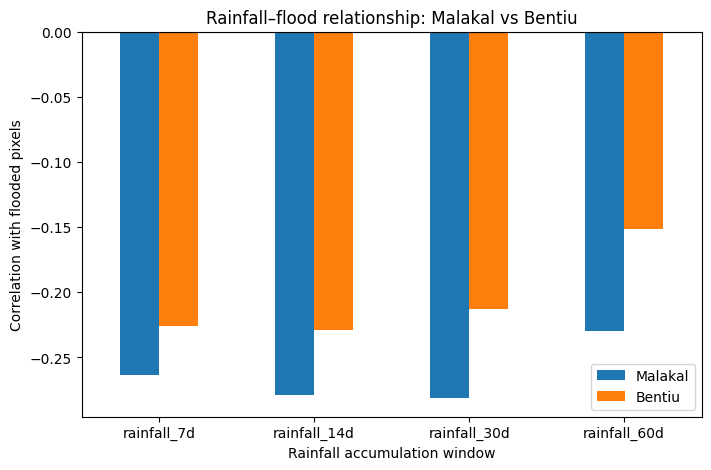

,Malakal,Bentiu
rainfall_7d,-0.263318,-0.225745
rainfall_14d,-0.278886,-0.229290
rainfall_30d,-0.281432,-0.212930
rainfall_60d,-0.230135,-0.151785


In [121]:
# This cell compares the rainfall–flood correlations found around Malakal with
# those around Bentiu. It outputs a grouped bar chart showing whether rainfall
# accumulation behaves consistently across the two regions.

malakal_corr = df[
    [
        "flood_pixels",
        "rainfall_7d",
        "rainfall_14d",
        "rainfall_30d",
        "rainfall_60d"
    ]
].corr()["flood_pixels"]

comparison = pd.DataFrame({
    "Malakal": malakal_corr[
        ["rainfall_7d", "rainfall_14d", "rainfall_30d", "rainfall_60d"]
    ],
    "Bentiu": bentiu_corr[
        ["rainfall_7d", "rainfall_14d", "rainfall_30d", "rainfall_60d"]
    ]
})

comparison.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.axhline(0)
plt.ylabel("Correlation with flooded pixels")
plt.xlabel("Rainfall accumulation window")
plt.title("Rainfall–flood relationship: Malakal vs Bentiu")
plt.xticks(rotation=0)
plt.show()

comparison

In [122]:
# This cell calculates the rainfall–flood correlation separately for each year
# in Malakal and Bentiu. It outputs a table showing whether the relationship
# between antecedent rainfall and flooding is consistent across both years
# and regions, providing a quick exploratory test of research question Q10.

def yearly_correlations(data, region_name):
    results = []

    temp = data.copy()
    temp["year"] = temp["date"].dt.year

    for year, year_data in temp.groupby("year"):
        results.append({
            "region": region_name,
            "year": year,
            "rainfall_7d": year_data["flood_pixels"].corr(
                year_data["rainfall_7d"]
            ),
            "rainfall_14d": year_data["flood_pixels"].corr(
                year_data["rainfall_14d"]
            ),
            "rainfall_30d": year_data["flood_pixels"].corr(
                year_data["rainfall_30d"]
            ),
            "rainfall_60d": year_data["flood_pixels"].corr(
                year_data["rainfall_60d"]
            )
        })

    return pd.DataFrame(results)


yearly_malakal = yearly_correlations(df, "Malakal")
yearly_bentiu = yearly_correlations(df_bentiu, "Bentiu")

yearly_comparison = pd.concat(
    [yearly_malakal, yearly_bentiu],
    ignore_index=True
)

yearly_comparison

,region,year,rainfall_7d,rainfall_14d,rainfall_30d,rainfall_60d
0,Malakal,2020,-0.224933,-0.237107,-0.246677,-0.233520
1,Malakal,2021,-0.298499,-0.322350,-0.328459,-0.219271
2,Malakal,2022,-0.329381,-0.342383,-0.332003,-0.269711
3,Bentiu,2020,-0.149219,-0.163924,-0.177925,-0.142738
4,Bentiu,2021,-0.264989,-0.267058,-0.246641,-0.126897
5,Bentiu,2022,-0.413081,-0.412549,-0.372208,-0.248163


### Preliminary observation — Regional and yearly comparison (Q10)

The rainfall–flood relationship appears relatively consistent across Malakal and Bentiu and across 2020–2022.

For both regions, flood extent is negatively correlated with antecedent rainfall for all tested accumulation windows (7, 14, 30 and 60 days). The strength of the relationship varies somewhat between years and regions, but the direction remains consistently negative.

The 7–30 day rainfall windows generally show stronger negative relationships than the 60-day window. Bentiu also tends to show slightly stronger negative correlations than Malakal, particularly in 2020 and 2022.

These exploratory results therefore provide **limited evidence of major regional or yearly differences in the local rainfall–flood relationship**. However, this analysis only considers local rainfall. Q10 also concerns hydrological conditions, which may show greater spatial or temporal differences.

The consistency of the negative rainfall relationships also suggests that local rainfall alone may not explain the timing and extent of observed flooding. This motivates further exploration of upstream hydrological signals in Q13.

## Q13 — Local rainfall vs upstream hydrological signals

**Research question:** *How do local rainfall and upstream hydrological signals differ across flood events and regions?*

The previous analysis showed that local rainfall alone does not have a simple positive relationship with observed flood extent around Malakal or Bentiu. This section therefore explores whether hydrological signals, such as river discharge, provide different information about flood events.

As an initial exploratory analysis, we first identify which available Dartmouth discharge stations could represent relevant hydrological signals for the selected study regions.

In [123]:
# This cell creates a table containing the available Dartmouth discharge stations
# and their locations. It outputs the station IDs, countries, and coordinates so
# we can determine which stations may provide relevant hydrological signals for
# Malakal and Bentiu before comparing them with observed flooding.

station_info = pd.DataFrame({
    "area_id": [
        100205, 1541, 1542, 1543, 1544
    ],
    "country": [
        "South Sudan", "Sudan", "Sudan", "Sudan", "Sudan"
    ],
    "latitude": [
        9.6, 12.4, 13.9, 14.9, 13.1
    ],
    "longitude": [
        31.6, 32.8, 32.4, 32.2, 33.9
    ]
})

station_info

,area_id,country,latitude,longitude
0,100205,South Sudan,9.6,31.6
1,1541,Sudan,12.4,32.8
2,1542,Sudan,13.9,32.4
3,1543,Sudan,14.9,32.2
4,1544,Sudan,13.1,33.9


In [124]:
# This cell displays the source code of the Dartmouth data-loading function.
# It outputs the implementation so we can identify where the complete station
# metadata file is stored and load all available station coordinates.

import inspect

print(inspect.getsource(loading.load_dartmouth_data))

def load_dartmouth_data() -> dict[int, pd.DataFrame]:
    """
    Returns a dictionary with for each station, referenced by the area id, the discharge over time.

    Also, this function loads the information Excel file, which provides for each station:
    - area id
    - station number
    - country
    - latitude
    - longitude   

    This data is downloaded from: https://floodobservatory.colorado.edu
    """
    base_path: str = './raw_data/Darthmouth Flood Observatory'
    data_info = pd.read_excel(base_path + '/information.xlsx')

    print("Information regarding each station:")
    print(data_info.head())

    area_ids = data_info['area id'].values

    # Create a dictionary with all stations data
    data = {}
    for area_id in area_ids:
        df = pd.read_csv(f'{base_path}/{area_id}_discharge.csv')
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date', drop=True).sort_index()
        data[area_id] = df

    print("Per station, we know:")
    pri

In [125]:
# This cell loads the complete Dartmouth discharge-station metadata from the
# information.xlsx file. It outputs the station number, area ID, country,
# latitude, and longitude for all available discharge stations so we can
# identify which stations may be relevant for Malakal and Bentiu.

station_info = pd.read_excel(
    "./raw_data/Darthmouth Flood Observatory/information.xlsx"
)

station_info

,station nr,area id,Country,latitude,longitude
0,334,100205,South Sudan,9.6,31.6
1,224,1541,Sudan,12.4,32.8
2,225,1542,Sudan,13.9,32.4
3,226,1543,Sudan,14.9,32.2
4,227,1544,Sudan,13.1,33.9
5,228,1545,Sudan,13.8,33.6
6,229,1547,Sudan,15.6,32.4
7,230,1548,Sudan,16.6,32.9
8,289,11808,Sudan,18.8,32.0
9,290,11842,Sudan,21.5,31.0


In [126]:
# This cell keeps only the columns needed for the Q13 exploratory analysis and
# sorts the stations by latitude. It outputs a compact overview of all available
# discharge stations and their locations.

station_info = station_info[
    ["station nr", "area id", "Country", "latitude", "longitude"]
].copy()

station_info.sort_values(
    "latitude",
    ascending=False
)

,station nr,area id,Country,latitude,longitude
9,290,11842,Sudan,21.5,31.0
8,289,11808,Sudan,18.8,32.0
7,230,1548,Sudan,16.6,32.9
6,229,1547,Sudan,15.6,32.4
3,226,1543,Sudan,14.9,32.2
10,293,28546,Sudan,14.9,35.8
2,225,1542,Sudan,13.9,32.4
5,228,1545,Sudan,13.8,33.6
4,227,1544,Sudan,13.1,33.9
1,224,1541,Sudan,12.4,32.8


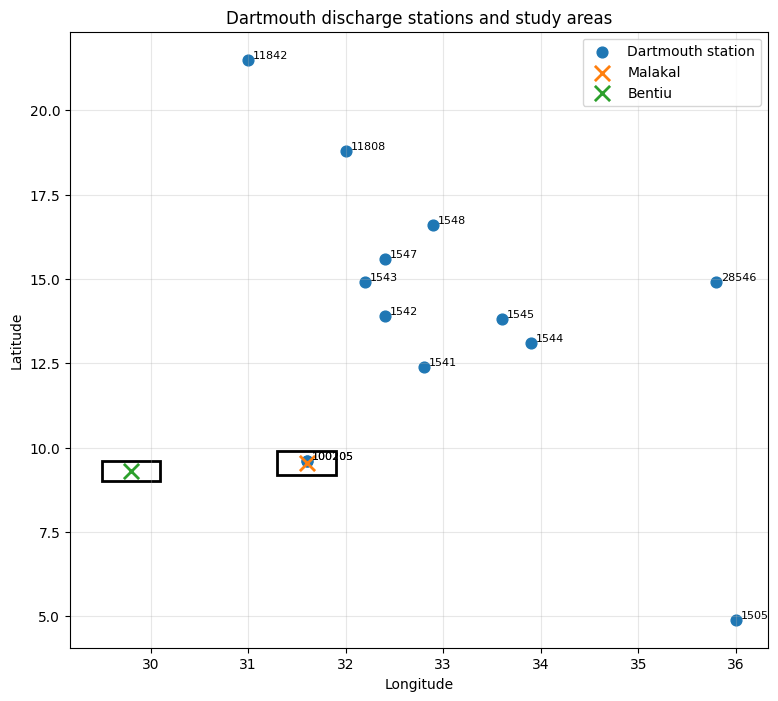

In [129]:
# This cell plots the Dartmouth discharge stations together with the Malakal
# and Bentiu study areas. It outputs a spatial overview showing which stations
# are near each analysis region, without assuming that nearby stations are
# hydrologically upstream.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(9, 8))

# Dartmouth stations
ax.scatter(
    station_info["longitude"],
    station_info["latitude"],
    s=60,
    label="Dartmouth station"
)

# Station labels
for _, row in station_info.iterrows():
    ax.text(
        row["longitude"] + 0.05,
        row["latitude"] + 0.05,
        str(int(row["area id"])),
        fontsize=8
    )

# Calculate the centre of each study area directly from the bounding boxes
# used in the previous analysis, rather than manually entering coordinates.

malakal_lon = (
    bbox_malakal["lon_min"] + bbox_malakal["lon_max"]
) / 2

malakal_lat = (
    bbox_malakal["lat_min"] + bbox_malakal["lat_max"]
) / 2

bentiu_lon = (
    bbox_bentiu["lon_min"] + bbox_bentiu["lon_max"]
) / 2

bentiu_lat = (
    bbox_bentiu["lat_min"] + bbox_bentiu["lat_max"]
) / 2

ax.scatter(
    malakal_lon,
    malakal_lat,
    marker="x",
    s=120,
    linewidths=2,
    label="Malakal"
)

ax.scatter(
    bentiu_lon,
    bentiu_lat,
    marker="x",
    s=120,
    linewidths=2,
    label="Bentiu"
)

# Malakal study-area box
malakal_box = Rectangle(
    (bbox_malakal["lon_min"], bbox_malakal["lat_min"]),
    bbox_malakal["lon_max"] - bbox_malakal["lon_min"],
    bbox_malakal["lat_max"] - bbox_malakal["lat_min"],
    fill=False,
    linewidth=2
)
ax.add_patch(malakal_box)

# Bentiu study-area box
bentiu_box = Rectangle(
    (bbox_bentiu["lon_min"], bbox_bentiu["lat_min"]),
    bbox_bentiu["lon_max"] - bbox_bentiu["lon_min"],
    bbox_bentiu["lat_max"] - bbox_bentiu["lat_min"],
    fill=False,
    linewidth=2
)
ax.add_patch(bentiu_box)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Dartmouth discharge stations and study areas")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In [134]:
# This cell identifies the dates with the largest observed flood extent in
# Malakal and Bentiu. It outputs the 10 highest flood-pixel observations in
# each region to help identify major flood periods for the Q13 event analysis.

print("Largest Malakal flood observations:")
display(
    df.nlargest(10, "flood_pixels")[
        ["date", "flood_pixels"]
    ]
)

print("Largest Bentiu flood observations:")
display(
    df_bentiu.nlargest(10, "flood_pixels")[
        ["date", "flood_pixels"]
    ]
)

Largest Malakal flood observations:


,date,flood_pixels
751,2022-01-21,2957.0
710,2021-12-11,2905.0
756,2022-01-26,2858.0
726,2021-12-27,2853.0
742,2022-01-12,2771.0
1093,2022-12-29,2719.0
712,2021-12-13,2693.0
758,2022-01-28,2625.0
703,2021-12-04,2583.0
694,2021-11-25,2571.0


Largest Bentiu flood observations:


,date,flood_pixels
1093,2022-12-29,37867.0
1095,2022-12-31,37640.0
1091,2022-12-27,37257.0
1088,2022-12-24,36417.0
1084,2022-12-20,36284.0
1083,2022-12-19,36042.0
1086,2022-12-22,35880.0
1081,2022-12-17,35835.0
1082,2022-12-18,35668.0
1089,2022-12-25,35657.0


In [135]:
# This cell selects up to three major flood-event peaks for each region while
# requiring peaks to be at least 60 days apart. It outputs representative dates
# for distinct major flood periods rather than multiple dates from the same event.

def select_event_peaks(data, n_events=3, min_gap_days=60):
    temp = data[["date", "flood_pixels"]].copy()
    temp = temp.sort_values("flood_pixels", ascending=False)

    selected = []

    for _, row in temp.iterrows():
        date = row["date"]

        if all(
            abs((date - previous_date).days) >= min_gap_days
            for previous_date in selected
        ):
            selected.append(date)

        if len(selected) == n_events:
            break

    return sorted(selected)


malakal_events = select_event_peaks(df)
bentiu_events = select_event_peaks(df_bentiu)

print("Malakal event peaks:")
for event in malakal_events:
    print(event.date())

print("\nBentiu event peaks:")
for event in bentiu_events:
    print(event.date())

Malakal event peaks:
2021-11-20
2022-01-21
2022-12-29

Bentiu event peaks:
2022-03-01
2022-10-28
2022-12-29


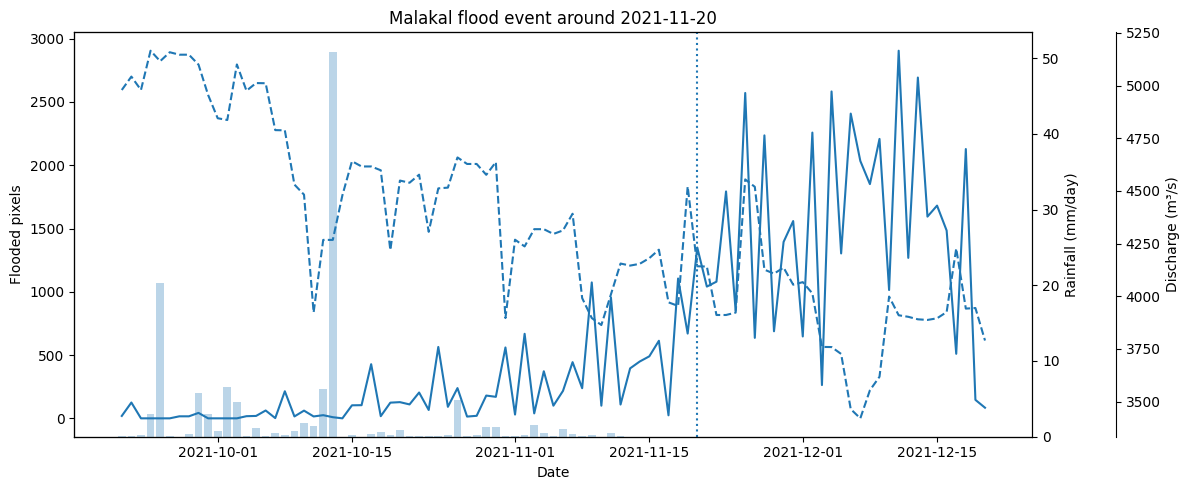

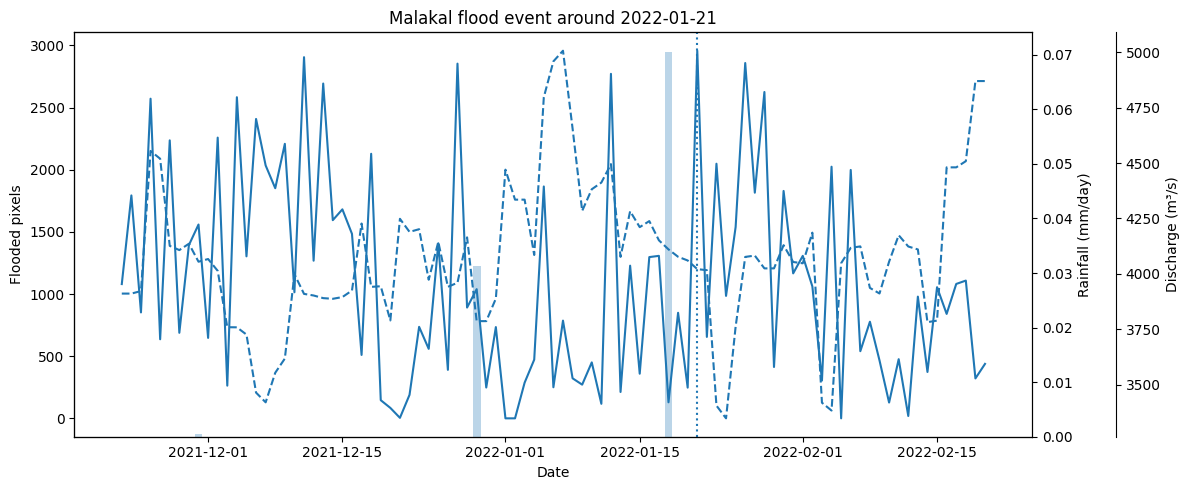

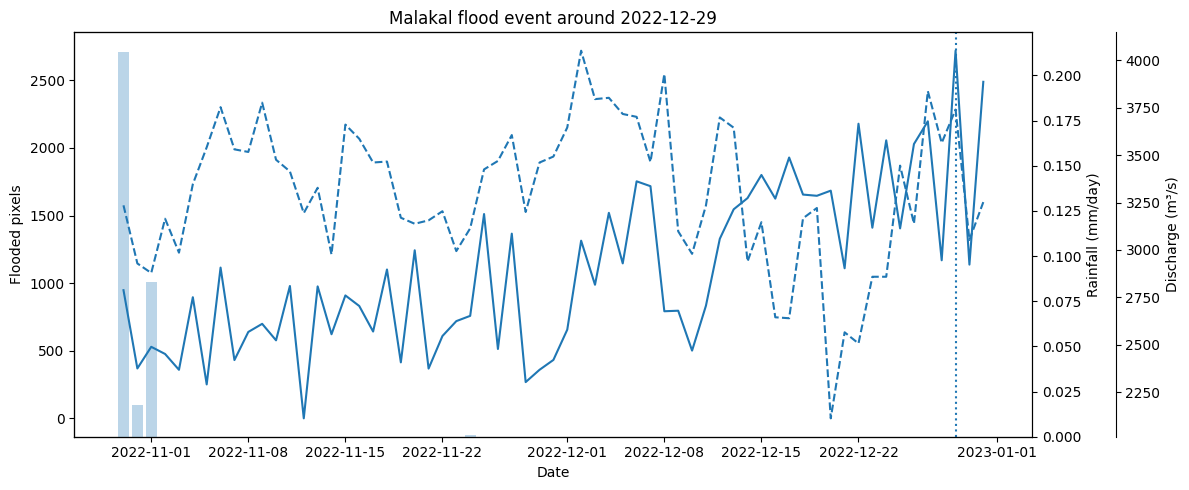

In [136]:
# This cell visualizes each selected Malakal flood event together with local
# rainfall and nearby Dartmouth discharge. It outputs one event plot per flood
# peak covering 60 days before and 30 days after the selected peak date.

for event_date in malakal_events:

    start = event_date - pd.Timedelta(days=60)
    end = event_date + pd.Timedelta(days=30)

    event_data = df[
        (df["date"] >= start) &
        (df["date"] <= end)
    ].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Flood extent
    ax1.plot(
        event_data["date"],
        event_data["flood_pixels"],
        label="Flood extent"
    )

    ax1.set_ylabel("Flooded pixels")
    ax1.set_xlabel("Date")

    # Rainfall
    ax2 = ax1.twinx()

    ax2.bar(
        event_data["date"],
        event_data["rainfall_mm"],
        alpha=0.3,
        label="Daily rainfall"
    )

    ax2.set_ylabel("Rainfall (mm/day)")

    # Discharge
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        event_data["date"],
        event_data["discharge"],
        linestyle="--",
        label="Discharge"
    )

    ax3.set_ylabel("Discharge (m³/s)")

    # Flood peak
    ax1.axvline(
        event_date,
        linestyle=":",
        label="Selected flood peak"
    )

    ax1.set_title(
        f"Malakal flood event around {event_date.date()}"
    )

    fig.tight_layout()
    plt.show()

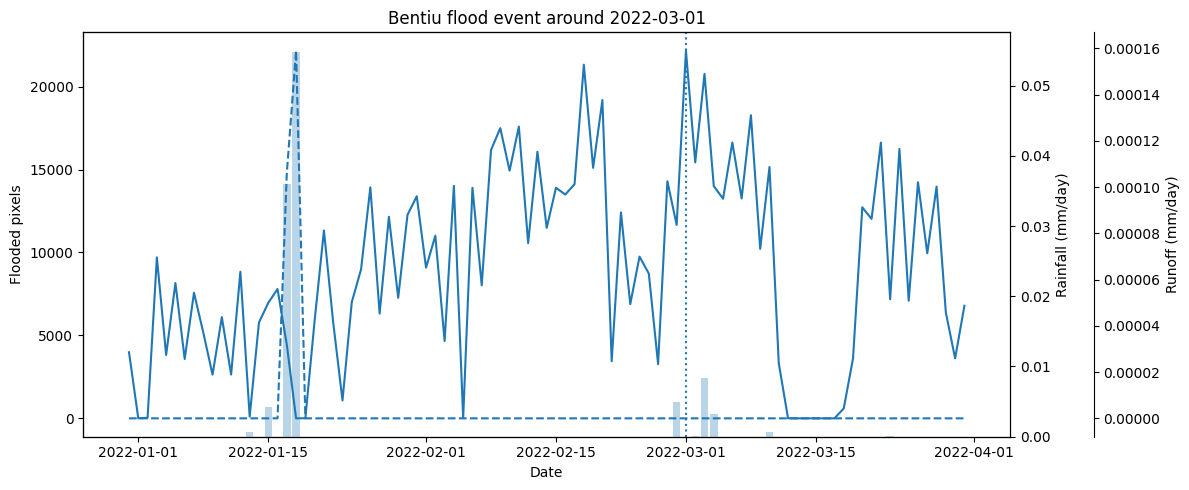

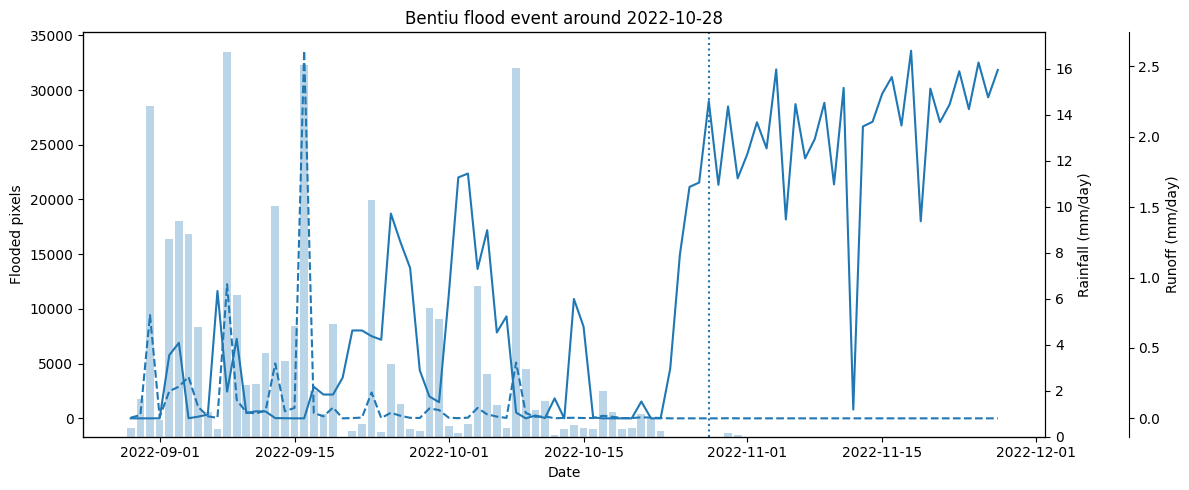

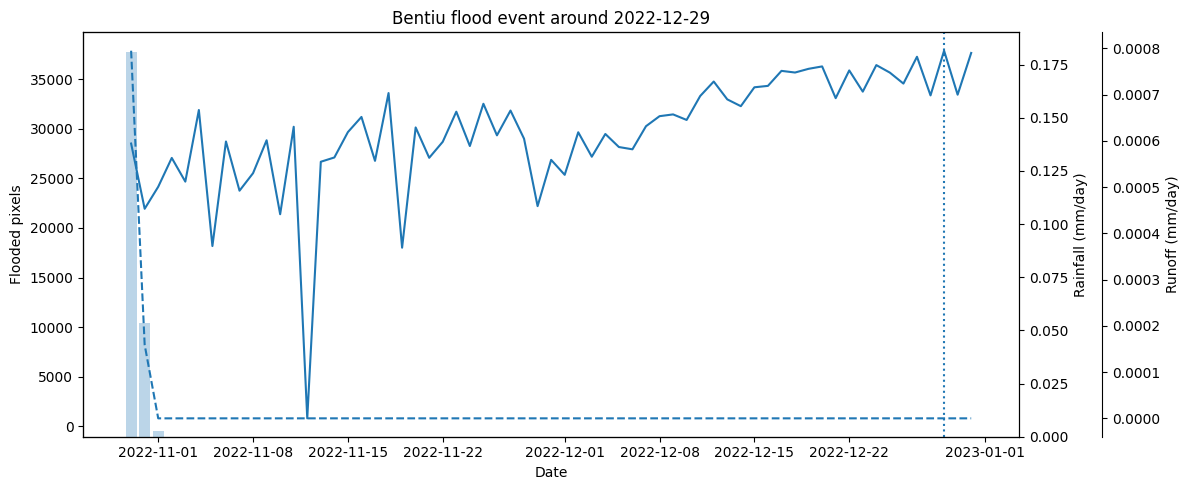

In [137]:
# This cell visualizes each selected Bentiu flood event together with local
# rainfall and ERA5 runoff. It outputs one event plot per flood peak covering
# 60 days before and 30 days after the selected peak date.

for event_date in bentiu_events:

    start = event_date - pd.Timedelta(days=60)
    end = event_date + pd.Timedelta(days=30)

    event_data = df_bentiu[
        (df_bentiu["date"] >= start) &
        (df_bentiu["date"] <= end)
    ].copy()

    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Flood extent
    ax1.plot(
        event_data["date"],
        event_data["flood_pixels"],
        label="Flood extent"
    )

    ax1.set_ylabel("Flooded pixels")
    ax1.set_xlabel("Date")

    # Rainfall
    ax2 = ax1.twinx()

    ax2.bar(
        event_data["date"],
        event_data["rainfall_mm"],
        alpha=0.3,
        label="Daily rainfall"
    )

    ax2.set_ylabel("Rainfall (mm/day)")

    # Runoff
    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))

    ax3.plot(
        event_data["date"],
        event_data["runoff_mm"],
        linestyle="--",
        label="ERA5 runoff"
    )

    ax3.set_ylabel("Runoff (mm/day)")

    # Flood peak
    ax1.axvline(
        event_date,
        linestyle=":",
        label="Selected flood peak"
    )

    ax1.set_title(
        f"Bentiu flood event around {event_date.date()}"
    )

    fig.tight_layout()
    plt.show()

In [138]:
# This cell summarizes rainfall and hydrological conditions before each selected
# Malakal flood peak. It outputs 30-day antecedent rainfall, mean discharge in
# the previous 30 days, discharge on the peak date, and maximum flood extent.

malakal_event_summary = []

for event_date in malakal_events:

    before = df[
        (df["date"] >= event_date - pd.Timedelta(days=30)) &
        (df["date"] < event_date)
    ]

    peak = df[df["date"] == event_date]

    malakal_event_summary.append({
        "region": "Malakal",
        "event_date": event_date,
        "rainfall_previous_30d_mm": before["rainfall_mm"].sum(),
        "mean_discharge_previous_30d": before["discharge"].mean(),
        "discharge_at_peak": peak["discharge"].iloc[0]
            if len(peak) > 0 else np.nan,
        "flood_pixels_at_peak": peak["flood_pixels"].iloc[0]
            if len(peak) > 0 else np.nan
    })

malakal_event_summary = pd.DataFrame(malakal_event_summary)

malakal_event_summary

,region,event_date,rainfall_previous_30d_mm,mean_discharge_previous_30d,discharge_at_peak,flood_pixels_at_peak
0,Malakal,2021-11-20,13.110003,4289.241971,4142.375236,1350.0
1,Malakal,2022-01-21,0.101805,4248.661704,4021.372067,2957.0
2,Malakal,2022-12-29,0.000000,3278.462953,3739.650172,2719.0


In [139]:
# This cell summarizes rainfall and runoff conditions before each selected
# Bentiu flood peak. It outputs 30-day antecedent rainfall, mean runoff in
# the previous 30 days, runoff on the peak date, and maximum flood extent.

bentiu_event_summary = []

for event_date in bentiu_events:

    before = df_bentiu[
        (df_bentiu["date"] >= event_date - pd.Timedelta(days=30)) &
        (df_bentiu["date"] < event_date)
    ]

    peak = df_bentiu[df_bentiu["date"] == event_date]

    bentiu_event_summary.append({
        "region": "Bentiu",
        "event_date": event_date,
        "rainfall_previous_30d_mm": before["rainfall_mm"].sum(),
        "mean_runoff_previous_30d": before["runoff_mm"].mean(),
        "runoff_at_peak": peak["runoff_mm"].iloc[0]
            if len(peak) > 0 else np.nan,
        "flood_pixels_at_peak": peak["flood_pixels"].iloc[0]
            if len(peak) > 0 else np.nan
    })

bentiu_event_summary = pd.DataFrame(bentiu_event_summary)

bentiu_event_summary

,region,event_date,rainfall_previous_30d_mm,mean_runoff_previous_30d,runoff_at_peak,flood_pixels_at_peak
0,Bentiu,2022-03-01,0.004874,0.000000,0.0,22164.0
1,Bentiu,2022-10-28,52.388405,0.025971,0.0,28984.0
2,Bentiu,2022-12-29,0.000000,0.000000,0.0,37867.0


In [141]:
# This cell displays the numerical summaries for the selected Malakal and Bentiu
# flood periods. It outputs antecedent rainfall and the available hydrological
# indicators so we can compare conditions across regions and flood periods.

print("Malakal flood-period summary:")
display(
    malakal_event_summary.round({
        "rainfall_previous_30d_mm": 2,
        "mean_discharge_previous_30d": 2,
        "discharge_at_peak": 2,
        "flood_pixels_at_peak": 0
    })
)

print("Bentiu flood-period summary:")
display(
    bentiu_event_summary.round({
        "rainfall_previous_30d_mm": 2,
        "mean_runoff_previous_30d": 3,
        "runoff_at_peak": 3,
        "flood_pixels_at_peak": 0
    })
)

Malakal flood-period summary:


,region,event_date,rainfall_previous_30d_mm,mean_discharge_previous_30d,discharge_at_peak,flood_pixels_at_peak
0,Malakal,2021-11-20,13.11,4289.24,4142.38,1350.0
1,Malakal,2022-01-21,0.10,4248.66,4021.37,2957.0
2,Malakal,2022-12-29,0.00,3278.46,3739.65,2719.0


Bentiu flood-period summary:


,region,event_date,rainfall_previous_30d_mm,mean_runoff_previous_30d,runoff_at_peak,flood_pixels_at_peak
0,Bentiu,2022-03-01,0.000000,0.000,0.0,22164.0
1,Bentiu,2022-10-28,52.389999,0.026,0.0,28984.0
2,Bentiu,2022-12-29,0.000000,0.000,0.0,37867.0


### Preliminary observation — Flood-event dynamics (Q13)

The selected flood periods show substantial differences in the timing of local rainfall, hydrological conditions, and observed flood extent.

For Malakal, the major flood peaks are not consistently associated with high local rainfall. The November 2021 period had some antecedent rainfall, while the January and December 2022 peaks occurred after almost no local rainfall during the previous 30 days. Nearby Dartmouth discharge also remained substantial during these periods, but its behaviour did not consistently coincide with maximum observed flood extent.

Bentiu shows similarly variable event dynamics. The October 2022 flood peak followed considerably wetter antecedent conditions (approximately 52 mm of rainfall during the previous 30 days), whereas the March and December 2022 peaks occurred with almost no local rainfall or ERA5 runoff during the preceding 30 days. In particular, very extensive flooding persisted in December despite locally dry conditions.

Together, these event-level observations reinforce the earlier finding that observed flood extent cannot be explained by simultaneous local rainfall alone. Some flood periods follow wetter antecedent conditions, while others occur or persist after local rainfall and runoff have largely disappeared. This suggests that flood persistence, delayed hydrological responses, accumulated water storage, and potentially upstream processes may be important.

However, the available Dartmouth station data limit the ability to directly test the upstream component of Q13 across regions. A discharge station is available near Malakal, but no comparable station is available near Bentiu, and the available metadata do not establish whether station 100205 represents an upstream signal. Therefore, the current data support investigation of differences between local rainfall and hydrological conditions around flood events, but additional hydrological information would be required to robustly analyse upstream signals across regions.

## Overall assessment of Q3, Q10 and Q13

This exploratory analysis was used to determine which of the three research questions appear most promising for further investigation. The results should be interpreted as preliminary: the analysis focuses on Malakal and Bentiu during 2020–2022 and uses relatively simple descriptive comparisons rather than formal hydrological or statistical modelling.

### Q3 — Which meteorological and hydrological conditions are associated with observed flood occurrence?

**Assessment: Strong candidate for further investigation.**

The exploratory results show that observed flooding has a non-trivial relationship with the available meteorological and hydrological variables. Around Malakal, flood extent was not positively associated with same-day local rainfall, runoff, or nearby river discharge. Testing accumulated rainfall over 7, 14, 30 and 60 days also did not reveal a simple positive rainfall–flood relationship.

The event-level analysis further showed that some major flood periods occurred or persisted after local rainfall had largely disappeared. This suggests that flood occurrence and extent may depend on delayed responses, antecedent conditions, flood persistence, water storage, river dynamics, or other hydrological processes rather than rainfall on the flood date itself.

Q3 therefore appears worth pursuing because the initial analysis reveals a clear phenomenon that requires further explanation. A deeper analysis could investigate temporal lags, seasonality, antecedent hydrological conditions, and combinations of meteorological and hydrological variables.

**Recommendation: PRIORITIZE.**

---

### Q10 — Are the meteorological and hydrological conditions associated with flooding consistent across different years and regions?

**Assessment: Useful, but currently less distinctive than Q3.**

The rainfall–flood relationship was surprisingly consistent across Malakal and Bentiu and across 2020–2022. For every tested year, region and rainfall accumulation window, the relationship between antecedent local rainfall and flood extent remained negative. The magnitude varied, but there was no major reversal in the overall pattern.

This provides preliminary evidence that the unusual timing between local rainfall and observed flooding is not unique to one year or one of the two study regions.

However, the current analysis tests the meteorological component of Q10 more strongly than the hydrological component. Comparable river-discharge observations are not available for both study regions, making a complete regional comparison of hydrological conditions difficult with the current Dartmouth dataset.

Q10 could still be valuable as a comparative extension of Q3, particularly if more regions, years, or comparable hydrological datasets are introduced. Based on the current exploration, however, it produces fewer contrasting patterns than initially expected.

**Recommendation: KEEP AS A SECONDARY / COMPARATIVE QUESTION.**

---

### Q13 — How do local rainfall and upstream hydrological signals differ across flood events and regions?

**Assessment: Scientifically interesting, but constrained by the available hydrological data.**

The event-level analysis shows clear temporal differences between local rainfall and observed flooding. Some flood periods followed substantial antecedent rainfall, while others occurred or persisted during locally dry conditions. This was visible in both Malakal and Bentiu and suggests that analysing individual flood events could provide useful information about flood dynamics.

For Malakal, nearby Dartmouth discharge provides an additional hydrological signal, but its behaviour does not consistently coincide with maximum flood extent. For Bentiu, no comparable nearby Dartmouth discharge station is available, so ERA5 runoff was used as a local hydrological indicator instead.

The main limitation is therefore the wording **"upstream hydrological signals."** The available Dartmouth metadata provide station coordinates but do not establish river connectivity or whether station 100205 is hydrologically upstream of the Malakal flood area. There is also no comparable station near Bentiu. Consequently, the current data cannot robustly answer the upstream component of Q13 across regions.

The event-based perspective remains promising, but fully pursuing Q13 would likely require additional river-network information, upstream discharge stations, water-level data, or another spatially consistent hydrological dataset.

**Recommendation: PROMISING, BUT ONLY PRIORITIZE IF BETTER UPSTREAM HYDROLOGICAL DATA CAN BE ESTABLISHED.**

---

### Final recommendation

Based on the exploratory results, **Q3 is the strongest question to pursue further**. The analysis consistently shows that local rainfall alone does not explain observed flood occurrence and extent, creating a clear motivation to investigate which combinations and time lags of meteorological and hydrological conditions are associated with flooding.

**Q10 is useful as a comparative extension of Q3.** Rather than treating it as a completely separate analysis, it could be used to test whether the relationships identified under Q3 generalize across years and regions.

**Q13 provides an interesting event-based perspective**, particularly because flood peaks frequently occur after local rainfall has declined. However, the current Dartmouth data are insufficient to robustly characterize upstream hydrological signals across both Malakal and Bentiu. Q13 therefore becomes substantially stronger only if suitable upstream discharge or river-network information can be added.

A logical direction for deeper analysis would therefore be:

**Q3 → identify the important meteorological/hydrological conditions and their timing**

**Q10 → test whether those relationships generalize across years and regions**

**Q13 → investigate event-scale hydrological mechanisms if suitable upstream data are available**